## Imports

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append("../src")

from models import (
    get_feature_columns,
    run_all_experiments,
    train_and_save_best_model,
    get_confusion_matrix,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Load Features

In [2]:
processed_path = "../data/processed/"
results_path   = "../results/"

features = pd.read_csv(processed_path + "features.csv")

print("Shape:", features.shape)
print("Columns:", features.columns.tolist())
print()
print("Class balance:")
print(features["performance_group"].value_counts())

Shape: (20788, 23)
Columns: ['id_student', 'pat_External_StudyMaterial_External_Discussion', 'pat_StudyMaterial_External_External_Discussion', 'pat_Discussion_Navigation_Discussion_External', 'pat_Discussion_Navigation_External_Navigation', 'pat_External_External_StudyMaterial_Discussion', 'pat_Discussion_External_Discussion_Navigation', 'pat_External_Discussion_External', 'pat_External_External_Navigation_Navigation', 'pat_Discussion_External_Discussion_Discussion', 'pat_Discussion_Navigation_External_Discussion', 'pat_Discussion_Quiz', 'total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions', 'performance_group']

Class balance:
performance_group
High    14323
Low      6465
Name: count, dtype: int64


In [3]:
static_cols, sequence_cols, hybrid_cols = get_feature_columns(features)

print(f"Static   features: {len(static_cols)}  — {static_cols}")
print(f"Sequence features: {len(sequence_cols)}")
print(f"Hybrid   features: {len(hybrid_cols)}")

Static   features: 10  — ['total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions']
Sequence features: 11
Hybrid   features: 21


## Train All Models

6 experiments total: 2 models × 3 feature sets
Each uses 5-fold stratified cross-validation.

In [4]:
print("Running experiments...\n")
results = run_all_experiments(features, cv=5)
print()
print("All results (sorted by F1):")
results

Running experiments...

  LogisticRegression     | static     ... F1=0.6968
  LogisticRegression     | sequence   ... F1=0.6663
  LogisticRegression     | hybrid     ... F1=0.7138
  RandomForest           | static     ... F1=0.8211
  RandomForest           | sequence   ... F1=0.7024
  RandomForest           | hybrid     ... F1=0.8222
  XGBoost                | static     ... F1=0.8062
  XGBoost                | sequence   ... F1=0.6724
  XGBoost                | hybrid     ... F1=0.8058
  LightGBM               | static     ... F1=0.8118
  LightGBM               | sequence   ... F1=0.7035
  LightGBM               | hybrid     ... F1=0.8119
  SVM                    | static     ... F1=0.7981
  SVM                    | sequence   ... F1=0.7046
  SVM                    | hybrid     ... F1=0.7866

All results (sorted by F1):


,model,features,accuracy,precision,recall,f1
0,RandomForest,hybrid,0.8312,0.8301,0.8312,0.8222
1,RandomForest,static,0.8302,0.8290,0.8302,0.8211
2,LightGBM,hybrid,0.8126,0.8114,0.8126,0.8119
3,LightGBM,static,0.8125,0.8113,0.8125,0.8118
4,XGBoost,static,0.8244,0.8383,0.8244,0.8062
5,XGBoost,hybrid,0.8239,0.8376,0.8239,0.8058
6,SVM,static,0.7970,0.7995,0.7970,0.7981
7,SVM,hybrid,0.7831,0.7927,0.7831,0.7866
8,LogisticRegression,hybrid,0.7029,0.7614,0.7029,0.7138
9,SVM,sequence,0.7251,0.7075,0.7251,0.7046


## Results Analysis

In [5]:
print("Best result:")
print(results.iloc[0].to_string())
print()
print("F1 by feature set:")
print(results.groupby("features")["f1"].max().sort_values(ascending=False))
print()
print("F1 by model:")
print(results.groupby("model")["f1"].max().sort_values(ascending=False))

Best result:
model        RandomForest
features           hybrid
accuracy           0.8312
precision          0.8301
recall             0.8312
f1                 0.8222

F1 by feature set:
features
hybrid      0.8222
static      0.8211
sequence    0.7046
Name: f1, dtype: float64

F1 by model:
model
RandomForest          0.8222
LightGBM              0.8119
XGBoost               0.8062
SVM                   0.7981
LogisticRegression    0.7138
Name: f1, dtype: float64


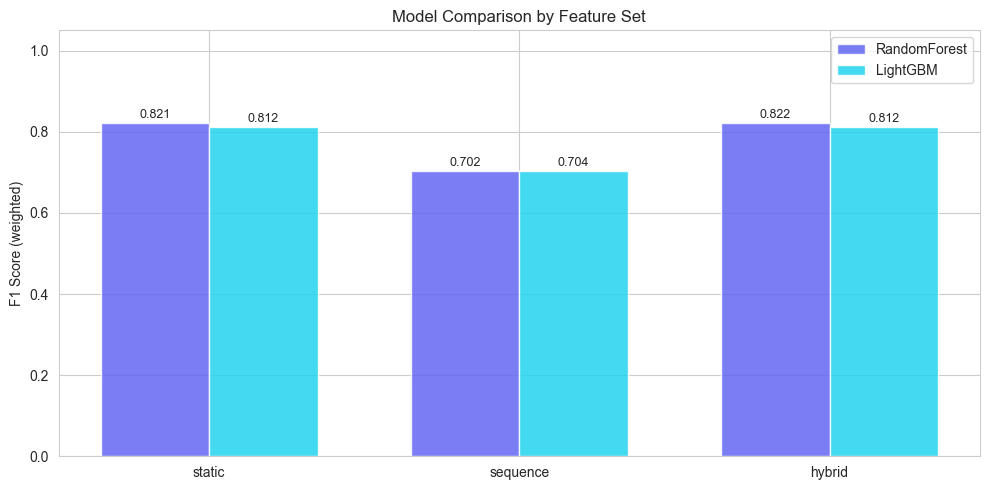

Saved to results/figures/model_comparison.png


In [6]:
# Bar chart — F1 by model and feature set
fig, ax = plt.subplots(figsize=(10, 5))

models     = results["model"].unique()
feat_sets  = ["static", "sequence", "hybrid"]
x          = np.arange(len(feat_sets))
width      = 0.35
colors     = ["#6366f1", "#22d3ee"]

for i, (model_name, color) in enumerate(zip(models, colors)):
    subset = results[results["model"] == model_name].set_index("features")
    vals   = [subset.loc[f, "f1"] if f in subset.index else 0 for f in feat_sets]
    bars   = ax.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(feat_sets)
ax.set_ylabel("F1 Score (weighted)")
ax.set_title("Model Comparison by Feature Set")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png", dpi=150)
plt.show()
print("Saved to results/figures/model_comparison.png")

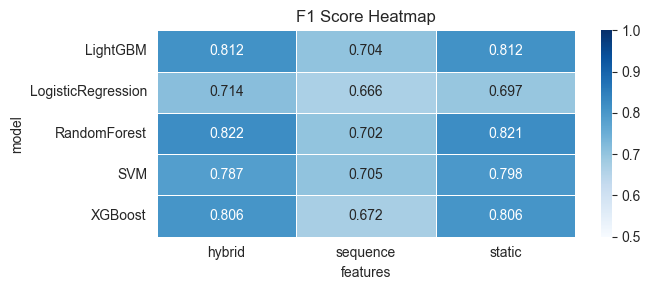

Saved to results/figures/model_heatmap.png


In [7]:
# Heatmap — all metrics
pivot = results.pivot_table(
    index="model",
    columns="features",
    values="f1",
)

plt.figure(figsize=(7, 3))
sns.heatmap(
    pivot, annot=True, fmt=".3f",
    cmap="Blues", linewidths=0.5,
    vmin=0.5, vmax=1.0,
)
plt.title("F1 Score Heatmap")
plt.tight_layout()
plt.savefig("../results/figures/model_heatmap.png", dpi=150)
plt.show()
print("Saved to results/figures/model_heatmap.png")

## Confusion Matrix — Best Model

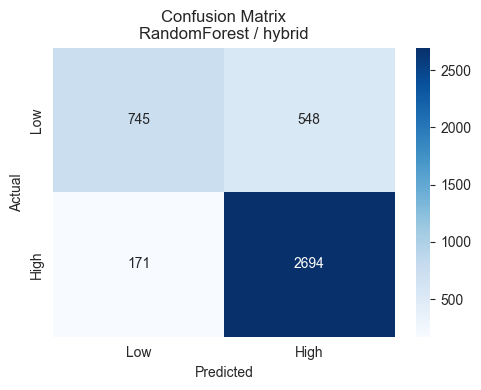

Saved to results/figures/confusion_matrix.png


In [8]:
best_model_name = results.iloc[0]["model"]
best_feat_name  = results.iloc[0]["features"]

cm = get_confusion_matrix(features, best_model_name, best_feat_name)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix\n{best_model_name} / {best_feat_name}")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix.png", dpi=150)
plt.show()
print("Saved to results/figures/confusion_matrix.png")

## Save Results & Best Model

In [9]:
# Save all results
results.to_csv(results_path + "model_results.csv", index=False)
print(f"Saved results to {results_path}model_results.csv")

Saved results to ../results/model_results.csv


In [10]:
# Train and save best model on full dataset
best_model_data = train_and_save_best_model(features, results, results_path)


Best model: RandomForest  |  features: hybrid  |  F1=0.8222
Saved to ../results/best_model.pkl


## Verify

In [11]:
import os, pickle

# Check model_results.csv
verify = pd.read_csv(results_path + "model_results.csv")
print("model_results.csv shape:", verify.shape)
print()
print(verify.to_string(index=False))
print()

# Check best_model.pkl
pkl_path = results_path + "best_model.pkl"
print("best_model.pkl exists:", os.path.exists(pkl_path))
with open(pkl_path, "rb") as f:
    loaded = pickle.load(f)
print("Model name:   ", loaded["model_name"])
print("Feature set:  ", loaded["feature_set"])
print("Feature cols: ", len(loaded["feature_cols"]), "columns")
print("F1 score:     ", loaded["metrics"]["f1"])

model_results.csv shape: (15, 6)

             model features  accuracy  precision  recall     f1
      RandomForest   hybrid    0.8312     0.8301  0.8312 0.8222
      RandomForest   static    0.8302     0.8290  0.8302 0.8211
          LightGBM   hybrid    0.8126     0.8114  0.8126 0.8119
          LightGBM   static    0.8125     0.8113  0.8125 0.8118
           XGBoost   static    0.8244     0.8383  0.8244 0.8062
           XGBoost   hybrid    0.8239     0.8376  0.8239 0.8058
               SVM   static    0.7970     0.7995  0.7970 0.7981
               SVM   hybrid    0.7831     0.7927  0.7831 0.7866
LogisticRegression   hybrid    0.7029     0.7614  0.7029 0.7138
               SVM sequence    0.7251     0.7075  0.7251 0.7046
          LightGBM sequence    0.7207     0.7024  0.7207 0.7035
      RandomForest sequence    0.7240     0.7058  0.7240 0.7024
LogisticRegression   static    0.6852     0.7573  0.6852 0.6968
           XGBoost sequence    0.7322     0.7417  0.7322 0.6724
Logist